# Explore here

In [1]:
# Your code here
import pandas as pd
df=pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv')
print(df.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [2]:
# Reload dataframe to guarantee original values before encoding
import pandas as pd
df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=416&path=medical_insurance_cost.csv')

# Convert binary categorical columns to numeric
df['sex'] = df['sex'].replace({'male': 1, 'female': 0}).astype(int)
df['smoker'] = df['smoker'].replace({'yes': 1, 'no': 0}).astype(int)

# Verify conversion
print(df[['sex', 'smoker']].head())



   sex  smoker
0    0       1
1    1       0
2    1       0
3    1       0
4    1       0


In [3]:
# Import utility to split data into train and test sets
from sklearn.model_selection import train_test_split

# Define features (X) with region included via one-hot encoding and target (y)
X = pd.get_dummies(df.drop(columns=['charges']), columns=['region'], drop_first=True)
y = df['charges']

# Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show resulting shapes
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (1070, 8)
X_test shape : (268, 8)
y_train shape: (1070,)
y_test shape : (268,)


In [4]:
# Import model and metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prepare numeric features and target
X_model = pd.get_dummies(df.drop(columns=['charges']), columns=['region'], drop_first=True)
y_model = df['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_model, y_model, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5

print('Linear Regression Results')
print(f"R²   : {r2_score(y_test, y_pred):.4f}")
print(f"MAE  : {mean_absolute_error(y_test, y_pred):.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")

Linear Regression Results
R²   : 0.7836
MAE  : 4181.19
MSE  : 33596915.85
RMSE : 5796.28


## Brief Conclusion

- The linear regression model is a good baseline.
- **R² = 0.7836** means it explains about **78%** of the variation in `charges`.
- **RMSE = 5796.28** and **MAE = 4181.19** show average prediction errors are still moderate.
- Overall, the model is useful, but it can be improved with better feature engineering or more advanced models.

In [5]:
# Additional optimization: tune Random Forest and compare with linear baseline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Prepare fully numeric data
X_enc = pd.get_dummies(df.drop(columns=['charges']), drop_first=True)
y_enc = df['charges']

# Split data
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_enc, y_enc, test_size=0.2, random_state=42)

# Baseline linear model
lin = LinearRegression()
lin.fit(X_train_m, y_train_m)
lin_pred = lin.predict(X_test_m)

# Tuned Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_grid = {
    'n_estimators': [300],
    'max_depth': [None, 12],
    'min_samples_leaf': [1, 2]
}
rf_search = GridSearchCV(rf, rf_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
rf_search.fit(X_train_m, y_train_m)
rf_pred = rf_search.best_estimator_.predict(X_test_m)

# Metrics helper
def eval_metrics(y_true, y_hat):
    mse_val = mean_squared_error(y_true, y_hat)
    return pd.Series({'R2': r2_score(y_true, y_hat), 'MAE': mean_absolute_error(y_true, y_hat), 'RMSE': mse_val**0.5})

# Compare models
compare = pd.DataFrame({
    'Linear_Baseline': eval_metrics(y_test_m, lin_pred),
    'RandomForest_Tuned': eval_metrics(y_test_m, rf_pred)
}).round(4)

print('Best RF params:', rf_search.best_params_)
display(compare)

Best RF params: {'max_depth': 12, 'min_samples_leaf': 2, 'n_estimators': 300}


,Linear_Baseline,RandomForest_Tuned
R2,0.7836,0.8725
MAE,4181.1945,2478.2985
RMSE,5796.2847,4449.8226


## Regplot and Heat Map

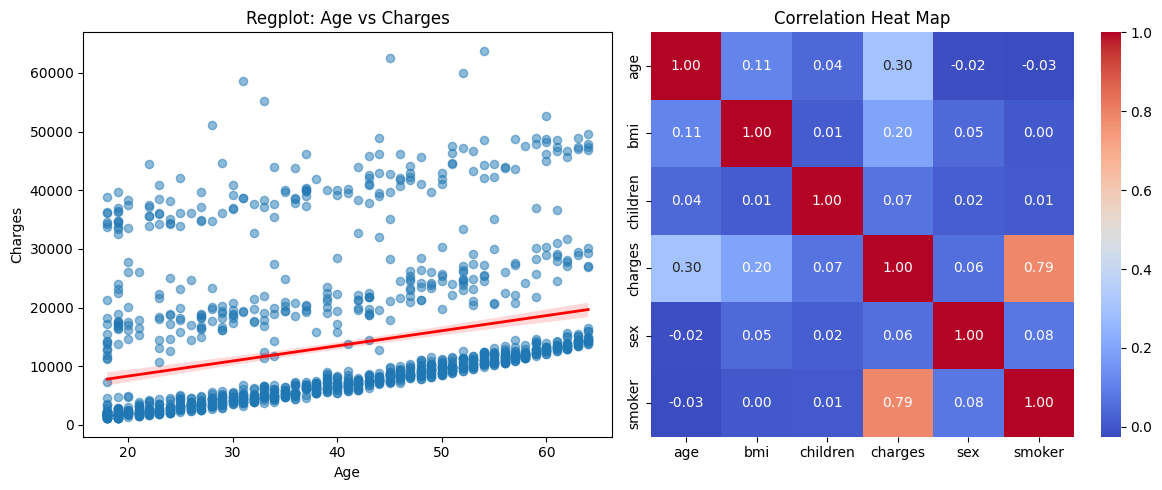

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

viz_data = df.copy()

fig, axis = plt.subplots(1, 2, figsize=(12, 5))

# 1) Regplot: Age vs Charges
sns.regplot(
    data=viz_data,
    x='age',
    y='charges',
    scatter_kws={'alpha': 0.5, 's': 35},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axis[0]
 )
axis[0].set_title('Regplot: Age vs Charges')
axis[0].set_xlabel('Age')
axis[0].set_ylabel('Charges')

# 2) Heat map: correlation matrix
corr_cols = ['age', 'bmi', 'children', 'charges', 'sex', 'smoker']
corr_matrix = viz_data[corr_cols].corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=axis[1])
axis[1].set_title('Correlation Heat Map')

plt.tight_layout()
plt.show()